<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/DBSCAN%20%20Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully!
                                       product_title  product_rating  \
0  BOYA BOYALINK 2 Wireless Lavalier Microphone f...             4.6   
1  LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...             4.3   
2  DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...             4.6   
3  Apple AirPods Pro 2 Wireless Earbuds, Active N...             4.6   
4  Apple AirTag 4 Pack. Keep Track of and find Yo...             4.8   

   total_reviews  purchased_last_month  discounted_price  original_price  \
0          375.0                 300.0             89.68          159.00   
1         2457.0                6000.0              9.99           15.99   
2         3044.0                2000.0            314.00          349.00   
3        35882.0               10000.0            162.24          162.24   
4        28988.0               10000.0             72.74           72.74   

  is_best_seller is_sponsored             has_coupon buy_box_availability  
0    

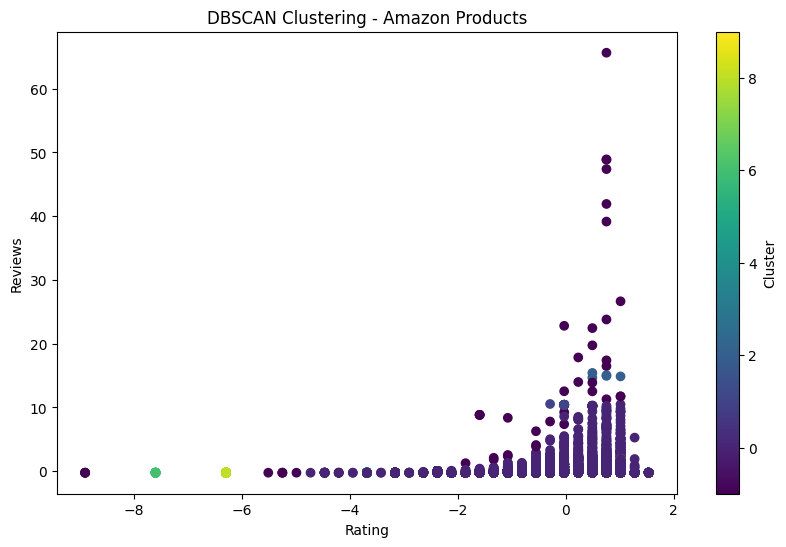

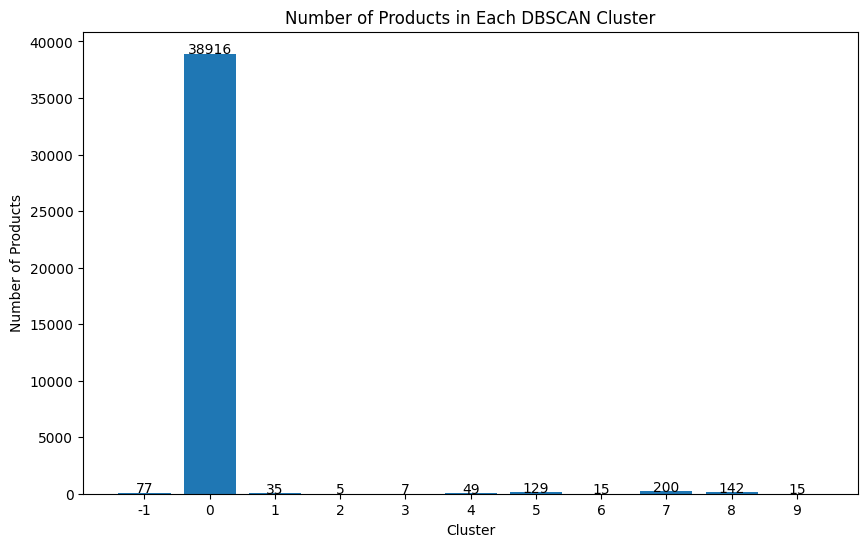

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score


# ============================================
# 1. LOAD DATASET
# ============================================

df = pd.read_csv("/content/amazon_products_sales_data_cleaned-selected-columns.csv")

print("Dataset loaded successfully!")
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns)


# ============================================
# 2. SELECT NUMERICAL FEATURES
# ============================================

# Check your dataset columns first.
# Change these column names if your CSV uses different names.

X = df[
    [
        "product_rating",
        "total_reviews",
        "discounted_price" # Or 'original_price' depending on which price you want to use
    ]
]


# ============================================
# 3. REMOVE MISSING VALUES
# ============================================

X = X.dropna()


# ============================================
# 4. SCALE FEATURES
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ============================================
# 5. DBSCAN MODEL
# ============================================

model = DBSCAN(
    eps=0.5,
    min_samples=5
)

clusters = model.fit_predict(X_scaled)


# ============================================
# 6. ADD CLUSTER TO DATASET
# ============================================

X["Cluster"] = clusters


# ============================================
# 7. DISPLAY CLUSTERS
# ============================================

print("\nCluster Results:")
print(X.head(20))


# ============================================
# 8. NUMBER OF CLUSTERS
# ============================================

unique_clusters = set(clusters)

number_of_clusters = len(
    unique_clusters
    - {-1}
)

print(
    "\nNumber of Clusters:",
    number_of_clusters
)


# ============================================
# 9. NUMBER OF NOISE POINTS
# ============================================

noise_points = list(
    clusters
).count(-1)

print(
    "Number of Noise Points:",
    noise_points
)


# ============================================
# 10. SILHOUETTE SCORE
# ============================================

# Remove noise points for silhouette calculation

mask = clusters != -1

if len(set(clusters[mask])) > 1:

    score = silhouette_score(
        X_scaled[mask],
        clusters[mask]
    )

    print(
        "DBSCAN Silhouette Score:",
        round(score, 4)
    )

else:

    print(
        "Silhouette Score cannot be calculated."
    )


# ============================================
# 11. GRAPH 1 - DBSCAN CLUSTERS
# ============================================

plt.figure(figsize=(10, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters
)

plt.xlabel("Rating")
plt.ylabel("Reviews")

plt.title(
    "DBSCAN Clustering - Amazon Products"
)

plt.colorbar(
    label="Cluster"
)

plt.show()


# ============================================
# 12. GRAPH 2 - CLUSTER SIZE
# ============================================

cluster_counts = pd.Series(
    clusters
).value_counts().sort_index()

plt.figure(figsize=(10, 6))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Products")

plt.title(
    "Number of Products in Each DBSCAN Cluster"
)

for i, value in enumerate(
    cluster_counts.values
):

    plt.text(
        i,
        value + 1,
        str(value),
        ha="center"
    )

plt.show()